### RNN from scatch

In [11]:
# %matplotlib inline allows for displaying plots directly in the Jupyter notebook
%matplotlib inline
import numpy as np
# seed = 42
# np.random.seed(seed)
# Pytorch is Deep learning framework
import torch
# NumPy is a library for numerical computations, with support for arrays and matrices
import numpy as np
# tqdm is used for creating progress bars to track the progress of for loops
from tqdm import tqdm
# Matplotlib is a plotting library, and we use it for tracking the loss values across iterations
import matplotlib.pyplot as plt
# IPython.display allows clearing the output in a Jupyter notebook cell
from IPython.display import clear_output
# use F to import Tanh and softmax activation function
from torch.nn import functional as F
# Importing the random module for generating random numbers/orders
import random
# Importing the list data type for storing collections of items.
from typing import List
import torch.nn.init as init

## 1. Defining the class and functions

In [12]:
class ElmanRNN:

  # Step 1 Initialises the Elman-style RNN Architecture
  def __init__(self, input_size, output_size, embedding_dim, hidden_size=64):
    '''
        Initialises the Elman-style RNN with random weights and zero biases.

        Args:
          input_size (int): Number of features in the input data.
          hidden_size (int): Number of neurons in the hidden layer.
          output_size (int): Number of classes in the output layer.
    '''
    # Weights
    '''
    randn returns a sample from the standard normal distribution.
    We divide by 1000 (just a value that seems to work with our setup).
    The goal is to have a better initialisation.
    The ultimate objective of different initialisation techniques is
    to ensure that our weights are neither too small nor too large,
    as this has a significant impact on training dynamics and neural network stability.
    '''
    self.hidden_size = hidden_size #make hidden size accessable to other functions in the class
    self.embeddings = {}

    # Weight matrices
    # self.U = torch.randn(hidden_size, hidden_size) / 1000
    # self.W = torch.randn(hidden_size, embedding_dim) / 1000
    # self.V = torch.randn(output_size, hidden_size) / 1000
    # self.E = torch.randn(embedding_dim, input_size) / 1000
    self.U = torch.empty(hidden_size, hidden_size)
    self.W = torch.empty(hidden_size, embedding_dim)
    self.V = torch.empty(output_size, hidden_size)
    self.E = torch.empty(embedding_dim, input_size)

    # Xavier init
    gain_tanh = init.calculate_gain("tanh")  # because hidden uses tanh
    init.xavier_uniform_(self.U, gain=gain_tanh)
    init.xavier_uniform_(self.W, gain=gain_tanh)
    init.xavier_uniform_(self.V)             # output layer: gain=1 is usually fine
    init.xavier_uniform_(self.E) 

    # Biases
    self.BU = torch.zeros(hidden_size, 1)
    self.BV = torch.zeros(output_size, 1)

  # Step 2: For activation functions, we will use their torch implementation instead of from-scratch

  # Step 3: Perform Forward propagation
  def forward(self, inputs, verbose:bool=False):
    '''
    Perform a forward pass of the RNN using the given inputs.
    Returns the final output and hidden state.
    - inputs is a list of arrays of one hot vectors with shape (input_size, 1) for each word in the sentence.
    - verbose: it's a common flag in programming, enable if you want to print meta information about your function.
    '''
    ## INSERT YOUR CODE HERE ##
    #initialise the hidden state to zero -> h: (self.hidden_size, 1)
    h = torch.zeros((self.hidden_size, 1))

    # store information for backward pass:

    # store the inputs which represent all sequences
    self.all_sequences = inputs

    # initialise a dict to store all hidden states, for this dict the key is the index of the time step,
    # and the value is the hidden state (h) at that step. Our first hidden state is the initialised one above,
    # and because we haven't started processing any input yet, we will give it time step index 0.
    self.previous_hidden_states = {0:h}
    self.embeddings = {}

    # Perform RNN for each time step, the input for each time step is x
    for i, x in enumerate(inputs):
      # calculate the next hidden state using equation 1
      # W (hidden_size, input_size) @ x (input_size, 1) -> (hidden_size, 1)
      # U (hidden_size, hidden_size) @ h (hidden_size, 1) -> (hidden_size, 1)
      e = self.E @ x
      self.embeddings[i+1] = e
      h = torch.tanh(self.U @ h + self.W @ e + self.BU)

      # store this hidden state in self.previous_hidden_states.
      # we already indexed the hidden state at step 0, the for loop counts from (0->(N-1))
      # we need to take care of that by adding 1 to the for loop counter.
      self.previous_hidden_states[i+1] = h

    if verbose:
      print(f"Hidden state size: {h.shape}")
      print(f"Hidden states: {self.previous_hidden_states}")

    # Compute the output using equation 2 and the last hidden state
    # V (output_size, hidden_size) @ h (hidden_size, 1) -> (output_size, 1)
    # Softmax has an argument called 'dim' that specifies the index dimension for applying softmax.
    # Applying softmax to the 'output_size' dimension provides the label distribution (which we are intreseted in).
    # Determine the index of the 'output_size' dimension to use as the value for 'dim'.
    y = F.softmax((self.V @ h + self.BV), dim=0)

    if verbose:
      print(f"Output size: {y.shape}")

    # return the output (y) and the last hidden state (h)
    return y, h

    ## END OF YOUR CODE ##

  # Step 4: Perform Backward propagation
  def backward_through_time(self, outputs, y, learn_rate=2e-2):
    '''
    Perform a backward pass of the RNN.
    - outputs: network predictions.
    - y: ground truth labels (targets).
    - learn_rate is a float.
    '''
    n = len(self.all_sequences)

    # Backpropagate through Output Layer:
    #target_labels or y  = 0 #index of correct label
    #outputs =[0.2, 0.8] #predictions
    #we will copy the outputs to variable d_y to indicate that,
    #we want the change in prediction compared to the target index
    #so that we can propagate this change to the network, to make better predictions the next time.
    #so d_y[y] = -0.8 (0.2 - 1)  and this is what our neural network needs to care about.
    d_y = outputs
    d_y[y] -= 1

    # Calculate dL/dV and dL/dBV.
    # Since the output vectors and the one-hot encoded target vectors(y) have different dimensions,
    # we perform the matrix multiplication using the transpose of the hidden state matrix (self.previous_hidden_states[n].T),
    # which matches the dimensionality of the output vectors.
    d_V = d_y @ self.previous_hidden_states[n].T
    d_BV = d_y

    # Backpropagate through time:
    # Initialise dL/dU, dL/dW, and dL/dBU to zero, because those are the sets of parameters,
    # to accumulate their gradients across all time steps.
    d_U = torch.zeros(self.U.shape)
    d_W = torch.zeros(self.W.shape)
    d_BU = torch.zeros(self.BU.shape)
    d_E = torch.zeros(self.E.shape)

    # Calculate dL/dh for the last h.
    # dL/dh = dL/dy * dy/dh
    d_h = self.V.T @ d_y

    for t in reversed(range(n)):
      # Backpropagate through Hidden Layer:
      # An intermediate value: dL/dh * (1 - h^2)
      # (1 - h^2) is Tanh derivative
      d_h_raw = ((1 - self.previous_hidden_states[t + 1] ** 2) * d_h)

      # dL/dBU = dL/dh * (1 - h^2)
      d_BU += d_h_raw

      # dL/dU = dL/dh * (1 - h^2) * h_{t-1}
      d_U += d_h_raw @ self.previous_hidden_states[t].T

      # dL/dW = dL/dh * (1 - h^2) * x
      e_t = self.embeddings[t+1]
      d_e_t = self.W.T @ d_h_raw

      x_t = self.all_sequences[t]
      d_E += d_e_t @ x_t.T
      
      d_W += d_h_raw @ e_t.T

      # Update hidden state gradient for next time step:
      # Next dL/dh = dL/dh * (1 - h^2) * U
      d_h = self.U.T @ d_h_raw

    # Clip to prevent exploding gradients. RNN and its variants suffer alot from this problem
    for d in [d_W, d_U, d_V, d_BU, d_BV, d_E]:
      torch.clip(d, -1, 1, out=d)

    # Update weights and biases using gradient descent.
    self.U -= learn_rate * d_U
    self.W -= learn_rate * d_W
    self.V -= learn_rate * d_V
    self.BU -= learn_rate * d_BU
    self.BV -= learn_rate * d_BV
    self.E -= learn_rate * d_E

  # Step 5: Training Loop
  def train(self, trainset_inputs: List[List[torch.tensor]], trainset_targets: List[List[torch.tensor]], epochs: int=100, learning_rate: float=0.01) -> None:
          '''
              Trains the Elman-style RNN using the specified training data.

              Args:
                trainset_inputs: contain input samples
                trainset_tragets: contain the corresponding labels.
                epochs (int): Number of training epochs. Default to 100.
                learning_rate (float): Learning rate for weight updates. Default to 0.01.
          '''

          self.losses = []
          for i, epoch in enumerate(range(epochs)):
              loss = 0
              num_correct = 0
              for x, y in zip(trainset_inputs, trainset_targets):
                  # Forward pass
                  outputs, _ = self.forward(x)
                  # Compute cross entropy loss/ Accuracy
                  loss -= torch.log(outputs[y])
                  num_correct += int(torch.argmax(outputs) == y)

                  # Backward pass through time
                  self.backward_through_time(outputs, y, learning_rate)

              self.losses.append((loss / len(trainset_inputs)).item())
              print(f"Train set accuracy at final Epoch {i+1}: {num_correct / len(trainset_inputs)}")


  def show_learning_curve(self) -> None:
        '''
        Displays the learning curve (loss curve) during training.
        '''
        plt.plot(self.losses)
        plt.xlabel('Epochs') # x axis label
        plt.ylabel('Cross-Entropy Loss') # y axis label
        plt.show()


  def test(self, testset_inputs: List[List[torch.tensor]], testset_targets: List[List[torch.tensor]]) -> float:
        '''
        Calculates the predictions for the given samples.

        Args:
            testset_inputs: contains test samples.
            testset_targets: contain the corresponding labels

        Returns:
            Accuracy: int
        '''
        num_correct = 0
        for x, y in zip(testset_inputs, testset_targets):
            y_pred, _ = self.forward(x)
            num_correct += int(torch.argmax(y_pred) == y)
        return num_correct / len(testset_inputs)


## 2. Train


In [13]:
# data
train_data = {
  'good': True,
  'bad': False,
  'happy': True,
  'sad': False,
  'not good': False,
  'not bad': True,
  'not happy': False,
  'not sad': True,
  'very good': True,
  'very bad': False,
  'very happy': True,
  'very sad': False,
  'i am happy': True,
  'this is good': True,
  'i am bad': False,
  'this is bad': False,
  'i am sad': False,
  'this is sad': False,
  'i am not happy': False,
  'this is not good': False,
  'i am not bad': True,
  'this is not sad': True,
  'i am very happy': True,
  'this is very good': True,
  'i am very bad': False,
  'this is very sad': False,
  'this is very happy': True,
  'i am good not bad': True,
  'this is good not bad': True,
  'i am bad not good': False,
  'i am good and happy': True,
  'this is not good and not happy': False,
  'i am not at all good': False,
  'i am not at all bad': True,
  'i am not at all happy': False,
  'this is not at all sad': True,
  'this is not at all happy': False,
  'i am good right now': True,
  'i am bad right now': False,
  'this is bad right now': False,
  'i am sad right now': False,
  'i was good earlier': True,
  'i was happy earlier': True,
  'i was bad earlier': False,
  'i was sad earlier': False,
  'i am very bad right now': False,
  'this is very good right now': True,
  'this is very sad right now': False,
  'this was bad earlier': False,
  'this was very good earlier': True,
  'this was very bad earlier': False,
  'this was very happy earlier': True,
  'this was very sad earlier': False,
  'i was good and not bad earlier': True,
  'i was not good and not happy earlier': False,
  'i am not at all bad or sad right now': True,
  'i am not at all good or happy right now': False,
  'this was not happy and not good earlier': False,
}

test_data = {
  'this is happy': True,
  'i am good': True,
  'this is not happy': False,
  'i am not good': False,
  'this is not bad': True,
  'i am not sad': True,
  'i am very good': True,
  'this is very bad': False,
  'i am very sad': False,
  'this is bad not good': False,
  'this is good and happy': True,
  'i am not good and not happy': False,
  'i am not at all sad': True,
  'this is not at all good': False,
  'this is not at all bad': True,
  'this is good right now': True,
  'this is sad right now': False,
  'this is very bad right now': False,
  'this was good earlier': True,
  'i was not happy and not good earlier': False,
}

18 unique words found
16
Train set accuracy at final Epoch 1: 0.43103448275862066
Train set accuracy at final Epoch 2: 0.41379310344827586
Train set accuracy at final Epoch 3: 0.4482758620689655
Train set accuracy at final Epoch 4: 0.4827586206896552
Train set accuracy at final Epoch 5: 0.5172413793103449
Train set accuracy at final Epoch 6: 0.5172413793103449
Train set accuracy at final Epoch 7: 0.5517241379310345
Train set accuracy at final Epoch 8: 0.5689655172413793
Train set accuracy at final Epoch 9: 0.6206896551724138
Train set accuracy at final Epoch 10: 0.6551724137931034
Train set accuracy at final Epoch 11: 0.6724137931034483
Train set accuracy at final Epoch 12: 0.6896551724137931
Train set accuracy at final Epoch 13: 0.6896551724137931
Train set accuracy at final Epoch 14: 0.7068965517241379
Train set accuracy at final Epoch 15: 0.7068965517241379
Train set accuracy at final Epoch 16: 0.7586206896551724
Train set accuracy at final Epoch 17: 0.7586206896551724
Train set acc

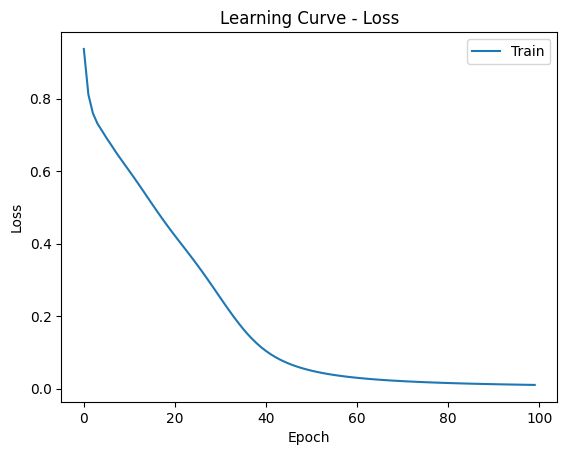

In [14]:
# Create the vocabulary.

# get unique words in the training corpus: set() removes duplicates
vocab = list(set([w for text in train_data.keys() for w in text.split(' ')]))
vocab_size = len(vocab)
print('%d unique words found' % vocab_size)

# Assign indices to each word.
word_to_idx = { w: i for i, w in enumerate(vocab) }
# test getting the index for one of the words from our dataset
print(word_to_idx['good'])

def createInput(text):
  '''
  Returns an array of one-hot vectors representing the words in the input text string.
  - text is a string
  - Each one-hot vector has shape (vocab_size, 1)
  '''
  inputs = []
  for w in text.split(' '):
    v = torch.zeros(vocab_size, 1)
    v[word_to_idx[w]] = 1
    inputs.append(v)
  return inputs

def processData(data: dict)-> tuple:
  '''
    Process the input data for training or inference.

    Args:
        data (dict): A dictionary containing input-output pairs.
    Returns:
        tuple: A tuple containing processed inputs and targets.
  '''
  items = list(data.items())
  random.shuffle(items)
  inputs = []
  targets = []
  for x, y in items:
    inputs.append(createInput(x))
    targets.append(int(y))
  return inputs, targets

## INSERT YOUR CODE HERE ##
# Initialise our Elman-style RNN
input_size = vocab_size # number of words in the vocabulary
output_size =  2 #num classes
emedding_dim = 8
# hidden size is by default set to 64, feel free to tweak it
model = ElmanRNN(input_size, output_size, emedding_dim)


# before start training, process train set dict using processData function:
x_train, y_train = processData(train_data)

#train the Elman-style RNN
model.train(x_train, y_train, epochs=100, learning_rate=0.01)
'''predictions, hidden_state = model.forward(X, verbose=True)
print(predictions)
model.backward_through_time(predictions, y_train)'''

#plot the learning curve
plt.plot(model.losses, label='Train')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Learning Curve - Loss')
plt.legend()

## END OF YOUR CODE ##

## 3. Evaluate

In [15]:
## INSERT YOUR CODE HERE ##

# process test set dict using processData function:
x_test, y_test = processData(test_data)

# test your model

accuracy = model.test(x_test, y_test)

# print Accuracy
print(f"Test set accuracy: {accuracy}")
## END OF YOUR CODE ##

Test set accuracy: 1.0


# Accuracy ~1.0 only possible using the xavier_transform otherwise performance is matched even with the embedding matrix at 0.5